Dealing with dates and times in pandas

In [25]:
import pandas as pd

In [26]:
df = pd.read_csv('Asian_paints.csv')

In [27]:
df.head()

,DateTime,Pre Open ASIANPAINTEQN,ASIANPAINTEQN
0,2025-06-13 09:00:59,2200.0,NaN
1,2025-06-13 09:01:59,2199.0,NaN
2,2025-06-13 09:02:59,2190.0,NaN
3,2025-06-13 09:03:59,2187.0,NaN
4,2025-06-13 09:04:59,2187.0,NaN


Now trying to get dayname for one value

In [28]:
df.loc[0, 'DateTime'].day_name()

AttributeError: 'str' object has no attribute 'day_name'

We got error because here the column is str datatype and we have to change it to datetime type

In [29]:
df['DateTime'] = pd.to_datetime(df['DateTime'], format = '%Y-%m-%d %H:%M:%S')

In [30]:
df.loc[0, 'DateTime'].day_name()

'Friday'

Now trying to get the dayname for entire datetime column(series datatype)

In [31]:
df['DateTime'].day_name()

AttributeError: 'Series' object has no attribute 'day_name'

We have to apply the date method to apply it for entire series object

In [32]:
df['DateTime'].dt.day_name()

0      Friday
1      Friday
2      Friday
3      Friday
4      Friday
        ...  
393    Friday
394    Friday
395    Friday
396    Friday
397    Friday
Name: DateTime, Length: 398, dtype: object

To view the oldest and latest dates

In [33]:
df['DateTime'].min()

Timestamp('2025-06-13 09:00:59')

In [34]:
df['DateTime'].max()

Timestamp('2025-06-13 15:59:48')

To view the time gap between these 2, use timedeltas

In [35]:
df['DateTime'].max() - df['DateTime'].min()

Timedelta('0 days 06:58:49')

In [36]:
filter = (df['DateTime'].dt.hour >= 14)
df.loc[filter]

,DateTime,Pre Open ASIANPAINTEQN,ASIANPAINTEQN
293,2025-06-13 14:00:58,NaN,2212.2
294,2025-06-13 14:01:59,NaN,2211.0
295,2025-06-13 14:02:59,NaN,2210.7
296,2025-06-13 14:03:57,NaN,2210.6
297,2025-06-13 14:04:59,NaN,2210.7
...,...,...,...
393,2025-06-13 15:52:45,NaN,2214.2
394,2025-06-13 15:55:39,NaN,2214.2
395,2025-06-13 15:56:44,NaN,2214.2
396,2025-06-13 15:58:41,NaN,2214.2


In [37]:
df['DateTime'].dt.hour

0       9
1       9
2       9
3       9
4       9
       ..
393    15
394    15
395    15
396    15
397    15
Name: DateTime, Length: 398, dtype: int32

If i want to find the average price between 10 to 11 

In [38]:
df.set_index('DateTime', inplace = True)

In [39]:
df['2025-06-13 10:00:00' : '2025-06-13 11:00:00']

,Pre Open ASIANPAINTEQN,ASIANPAINTEQN
DateTime,,
2025-06-13 10:00:57,NaN,2200.5
2025-06-13 10:01:58,NaN,2200.3
2025-06-13 10:02:53,NaN,2201.0
2025-06-13 10:03:54,NaN,2200.2
2025-06-13 10:04:54,NaN,2200.3
2025-06-13 10:05:55,NaN,2201.2
2025-06-13 10:06:55,NaN,2201.2
2025-06-13 10:07:47,NaN,2201.3
2025-06-13 10:08:53,NaN,2198.6


In [40]:
df['2025-06-13 10:00:00' : '2025-06-13 11:00:00']['ASIANPAINTEQN']

DateTime
2025-06-13 10:00:57    2200.5
2025-06-13 10:01:58    2200.3
2025-06-13 10:02:53    2201.0
2025-06-13 10:03:54    2200.2
2025-06-13 10:04:54    2200.3
2025-06-13 10:05:55    2201.2
2025-06-13 10:06:55    2201.2
2025-06-13 10:07:47    2201.3
2025-06-13 10:08:53    2198.6
2025-06-13 10:09:57    2197.4
2025-06-13 10:10:55    2196.6
2025-06-13 10:11:54    2196.7
2025-06-13 10:12:59    2198.9
2025-06-13 10:13:59    2199.3
2025-06-13 10:14:58    2199.9
2025-06-13 10:15:55    2197.7
2025-06-13 10:16:58    2198.0
2025-06-13 10:17:56    2196.9
2025-06-13 10:18:59    2197.2
2025-06-13 10:19:55    2196.5
2025-06-13 10:20:57    2195.5
2025-06-13 10:21:54    2194.1
2025-06-13 10:22:56    2193.3
2025-06-13 10:23:59    2194.8
2025-06-13 10:24:59    2196.7
2025-06-13 10:25:57    2197.0
2025-06-13 10:26:59    2197.0
2025-06-13 10:27:56    2197.3
2025-06-13 10:28:59    2196.0
2025-06-13 10:29:56    2196.3
2025-06-13 10:30:59    2193.8
2025-06-13 10:31:59    2193.6
2025-06-13 10:32:59    2194.5
2

In [41]:
df['2025-06-13 10:00:00' : '2025-06-13 11:00:00']['ASIANPAINTEQN'].mean()

2198.11

In [42]:
df['2025-06-13 10:00:00' : '2025-06-13 11:00:00']['ASIANPAINTEQN'].max()

2203.5

Now i want to know th high close in each hour, we can do this by resamplinh

In [43]:
df['ASIANPAINTEQN'].resample('h')

In [47]:
highs = df['ASIANPAINTEQN'].resample('h').max()
highs

DateTime
2025-06-13 09:00:00    2202.9
2025-06-13 10:00:00    2203.5
2025-06-13 11:00:00    2207.2
2025-06-13 12:00:00    2209.8
2025-06-13 13:00:00    2215.1
2025-06-13 14:00:00    2215.4
2025-06-13 15:00:00    2216.6
Freq: h, Name: ASIANPAINTEQN, dtype: float64

We can even plot this ones

In [48]:
%matplotlib inline

<Axes: xlabel='DateTime'>

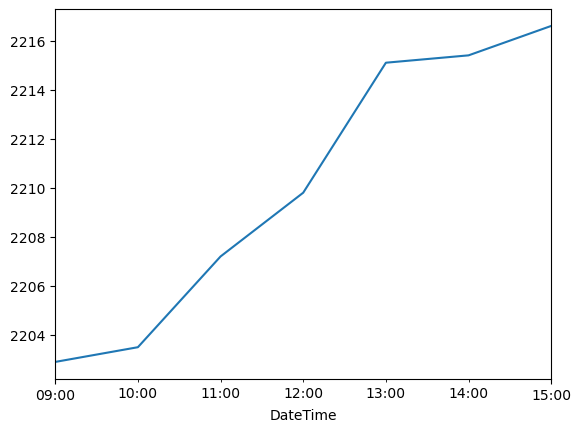

In [49]:
highs.plot()